<font size=6><b>Lec04.딥러닝 CNN - mnist 이미지 분류
* https://keras.io/api/datasets/mnist/

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split                     

#----------------------------------------------------------------------------------- ML모델 
from sklearn.tree import DecisionTreeClassifier 
#----------------------------------------------------------------------------------  DL모델 
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
#----------------------------------------------------------------------------------- 평가
from sklearn.metrics  import accuracy_score,      f1_score


import warnings
warnings.filterwarnings('ignore')

sns.set()

#-------------------- 차트 관련 속성 (한글처리, 그리드) -----------
plt.rcParams['font.family']= 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

#-------------------- 주피터 , 출력결과 넓이 늘리기 ---------------
# from IPython.core.display import display, HTML
from IPython.display import display, HTML
display(HTML("<style>.container{width:100% !important;}</style>"))
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)
pd.set_option('max_colwidth', None)

# <b>Data Load

* MNIST digits classification dataset
* train : 60,000 28x28 grayscale images of the 10 digits
* test  : 10,000 28x28 grayscale images of the 10 digits

In [2]:
from tensorflow.keras.datasets.mnist import load_data

In [3]:
(x_train, y_train), (x_test, y_test) = load_data(path="mnist.npz")
# assert x_train.shape == (60000, 28, 28)
# assert x_test.shape == (10000, 28, 28)
# assert y_train.shape == (60000,)
# assert y_test.shape == (10000,)

In [4]:
print(  x_train.shape, y_train.shape, x_test.shape, y_test.shape )

(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


## Target feature

[5 0 4 1 9 2 1 3 1 4]


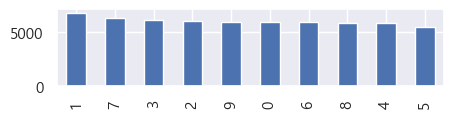

In [5]:
print(  y_train[:10] )
plt.figure(figsize=(5,1))
pd.Series(y_train).value_counts().plot(kind='bar')
plt.show()

[7 2 1 0 4 1 4 9 5 9]


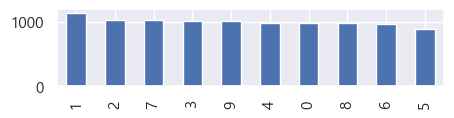

In [6]:
print(  y_test[:10] )
plt.figure(figsize=(5,1))
pd.Series(y_test).value_counts().plot(kind='bar')
plt.show()

## Data Set

In [7]:
#x_train[0]

# <b>EDA

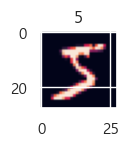

In [8]:
plt.figure(figsize=(1,1))
plt.imshow(x_train[0])
plt.title(y_train[0])
plt.show()

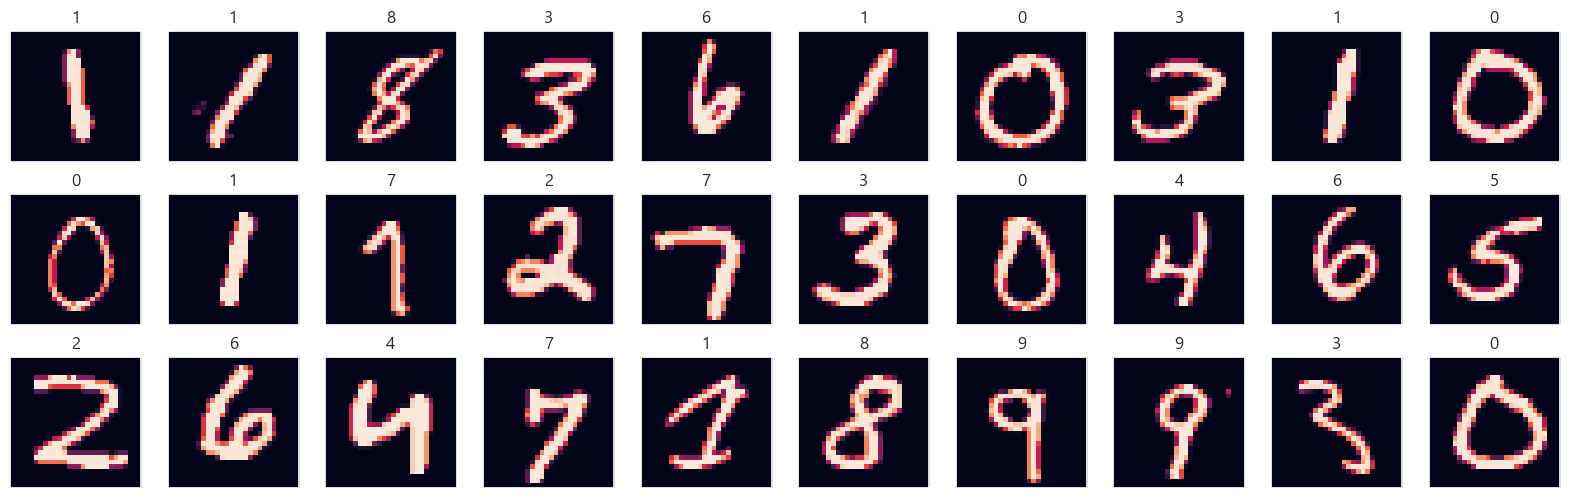

In [9]:
fig, axes = plt.subplots(3,10, figsize=(20,6))
for i, px_arr in enumerate(x_train[200:230]) : 
    row = i // 10
    col = i % 10
    axes[row][col].imshow(px_arr)
    axes[row][col].set_title(y_train[200:230][i])
    # Hide axes,grid
    axes[row][col].grid(False)
    axes[row][col].set_xticks([])
    axes[row][col].set_yticks([])
plt.show()

# <b>전처리 & 가공
* 픽셀 ( 0 ~ 255 ) 스케일링 : MinMaxScaler
* 컬러, 노이즈, 채도, 확대축소, 리사이즈 : OpenCV
* 이미지 증강(Augmentation)

## 스케일링 : MinMaxScaler
* / 255 : 픽셀 ( 0 ~ 255 ) --> (0 ~ 1)

In [10]:
x_train = x_train / 255
x_test = x_test / 255
#x_train[0]

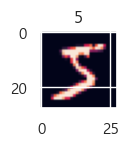

In [11]:
plt.figure(figsize=(1,1))
plt.imshow(x_train[0])
plt.title(y_train[0])
plt.show()

## 흑백처리

``` python
import cv2 

img1 = cv2.imread('/file_load_path/FILE_NAME1.jpg') 
print(img1.shape)  # (h, w, c=3) 

img1_gray = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
print(img1_gray.shape)  # (h, w)

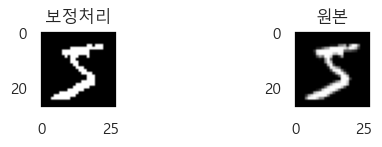

In [12]:
th = 0.5
x_trian_bin = np.where(x_train>th, 1.0, 0.0)
x_test_bin  = np.where(x_test >th, 1.0, 0.0)
plt.figure(figsize=(6,1))

plt.subplot(1,2,1)
plt.imshow(x_trian_bin[0].reshape(28,28), cmap='gray')
plt.grid(False)
plt.title("보정처리")

plt.subplot(1,2,2)
plt.imshow(x_train[0].reshape(28,28), cmap='gray')
plt.grid(False)
plt.title("원본")

plt.show()

# <b>모델

## <b>ML

In [15]:
x_train[0].shape  ,  x_train[0].reshape(1, 784).shape

((28, 28), (1, 784))

In [17]:
x_train.reshape(60000, -1).shape

(60000, 784)

In [21]:
model = DecisionTreeClassifier(random_state=4545)
model.fit(x_train.reshape(60000, -1)   ,  y_train)
pred = model.predict( x_test.reshape(10000, -1)  )
accuracy = accuracy_score(y_test ,  pred)
print(f"accuracy : {accuracy:.4f}")

accuracy : 0.8756


## <b>DL

In [27]:
del model

In [28]:
model = Sequential([
    Dense(units=10, activation="relu" , input_dim=784  ),   #----- input layer
    Dense(units=16, activation="relu"                  ),   #----- hidden layer 3
    Dense(units=24, activation="relu"                  ),    
    Dense(units=8,  activation="relu"                  ),
    Dense(units=10,  activation="softmax"              )    #----- output layer   
 ])
model.compile(loss="sparse_categorical_crossentropy" , optimizer="adam",  metrics=["accuracy"])   #-------------------- l o m

In [29]:
X80 = x_train.reshape(60000, -1)
y80 = y_train
X20 = x_test.reshape(10000, -1)
y20 = y_test

res = model.fit(X80,y80,     epochs=20 ,   validation_data = (X20,y20)  )
# res
loss,acc = model.evaluate(X20, y20)
print(f"acc : {acc:.4f} , loss:{loss:.4f} " )

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.7869 - loss: 0.7030 - val_accuracy: 0.8994 - val_loss: 0.3595
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9109 - loss: 0.3193 - val_accuracy: 0.9190 - val_loss: 0.2813
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9247 - loss: 0.2634 - val_accuracy: 0.9216 - val_loss: 0.2790
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9305 - loss: 0.2399 - val_accuracy: 0.9267 - val_loss: 0.2559
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9345 - loss: 0.2243 - val_accuracy: 0.9278 - val_loss: 0.2530
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9372 - loss: 0.2143 - val_accuracy: 0.9346 - val_loss: 0.2270
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9394 - loss: 0.2043 - val_accuracy: 0.9349 - val_loss: 0.2267
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9414 - loss: 0.1963 - 

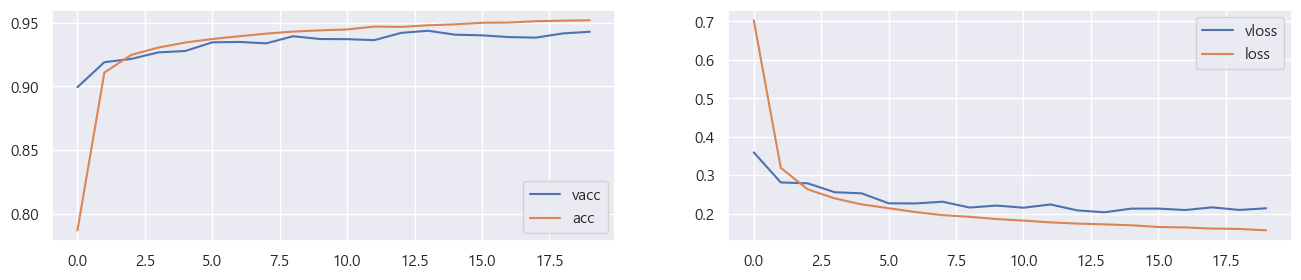

In [30]:
plt.figure(figsize=(16,3))
plt.subplot(1,2,1)
vacc = res.history["val_accuracy"]
acc  = res.history["accuracy"]
plt.plot(range(20), vacc , label="vacc")
plt.plot(range(20), acc  , label="acc")
plt.legend()

plt.subplot(1,2,2)
vloss = res.history["val_loss"]
loss = res.history["loss"]
plt.plot(range(20),vloss , label="vloss")
plt.plot(range(20),loss  , label="loss")
plt.legend()
plt.show()

### 오답 체크

In [36]:
print(  np.argmax( np.array([2.67647420e-06, 1.02145410e-10, 1.75441804e-04, 5.94187586e-04,
        2.39354478e-12, 1.42218014e-05, 6.53052612e-11, 9.98962641e-01,
        3.58910729e-05, 2.14890184e-04]))  )

7


In [41]:
proba = model.predict(X20)
# proba[:5]
pred = np.argmax( proba, axis=1 )
pred

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 689us/step


array([7, 2, 1, ..., 4, 5, 6], shape=(10000,))

In [44]:
pred.shape , y_test.shape

((10000,), (10000,))

In [46]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, pred)
print( cm ) 

[[ 950    0    4    2    0    9    6    4    3    2]
 [   0 1115    3    5    0    1    2    3    6    0]
 [   5    2  961   18    6    4    6   10   19    1]
 [   0    2   12  948    0   26    0    4   12    6]
 [   3    1    7    5  909    3    3    9    7   35]
 [   8    1    0   40    0  825    7    1    6    4]
 [  13    2    8    0    7   15  904    2    6    1]
 [   1    7   14    9    4    4    0  971    1   17]
 [   0   10    8   16    4   15    2    6  910    3]
 [   6    6    0   18   10    5    1   19    8  936]]


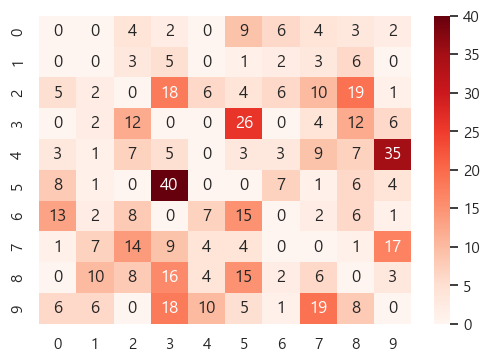

In [56]:
cmdf = pd.DataFrame(cm)
for i in range(10):
    cmdf.iloc[i,i] = 0   #---- 대각방향 정답 (정답빼고 오답만 보자)

plt.figure(figsize=(6,4))
sns.heatmap(cmdf, cmap="Reds", fmt='d', annot=True)
plt.show()

In [89]:
oxdf = pd.DataFrame( {"y":y_test,  "pred":pred })
oxdf["img"] = list( x_test.reshape(10000,-1) )
print(oxdf.shape)
oxdf.head(1)

(10000, 3)


,y,pred,img
0,7,7,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...]"


In [93]:
xdf = oxdf [ oxdf['y'] != oxdf['pred'] ]
print(xdf.shape)
xdf.head(1)

(571, 3)


,y,pred,img
7,9,3,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...]"


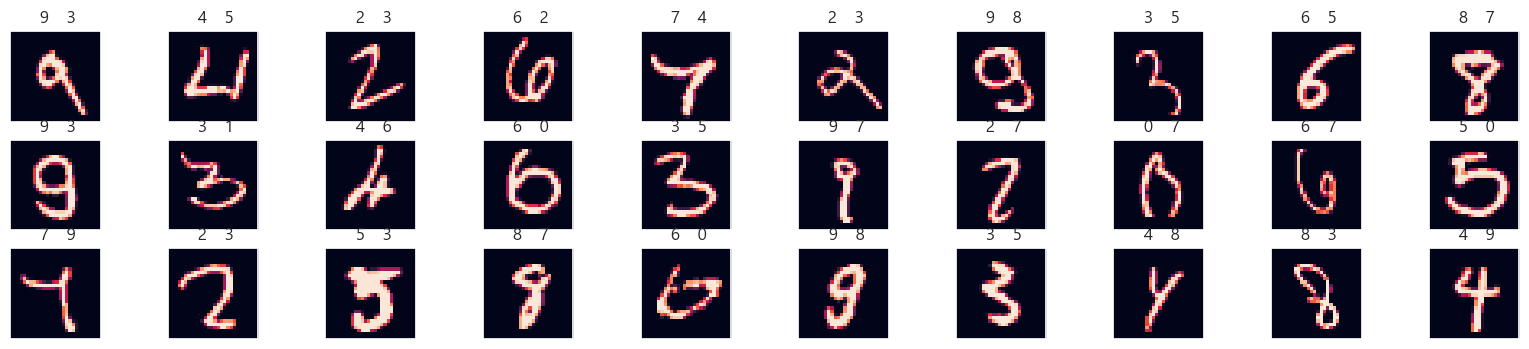

In [108]:
fig, axes = plt.subplots(3,10, figsize=(20,4))
for i, px_list in enumerate(xdf.iloc[:30, 2]) : 
    row = i // 10
    col = i % 10
    axes[row][col].imshow(  np.array(px_list)) # -- (28*28)
    axes[row][col].set_title( f" {xdf.iloc[i, 0]}   {xdf.iloc[i, 1]}"  )
    # Hide axes,grid
    axes[row][col].grid(False)
    axes[row][col].set_xticks([])
    axes[row][col].set_yticks([])
plt.show()